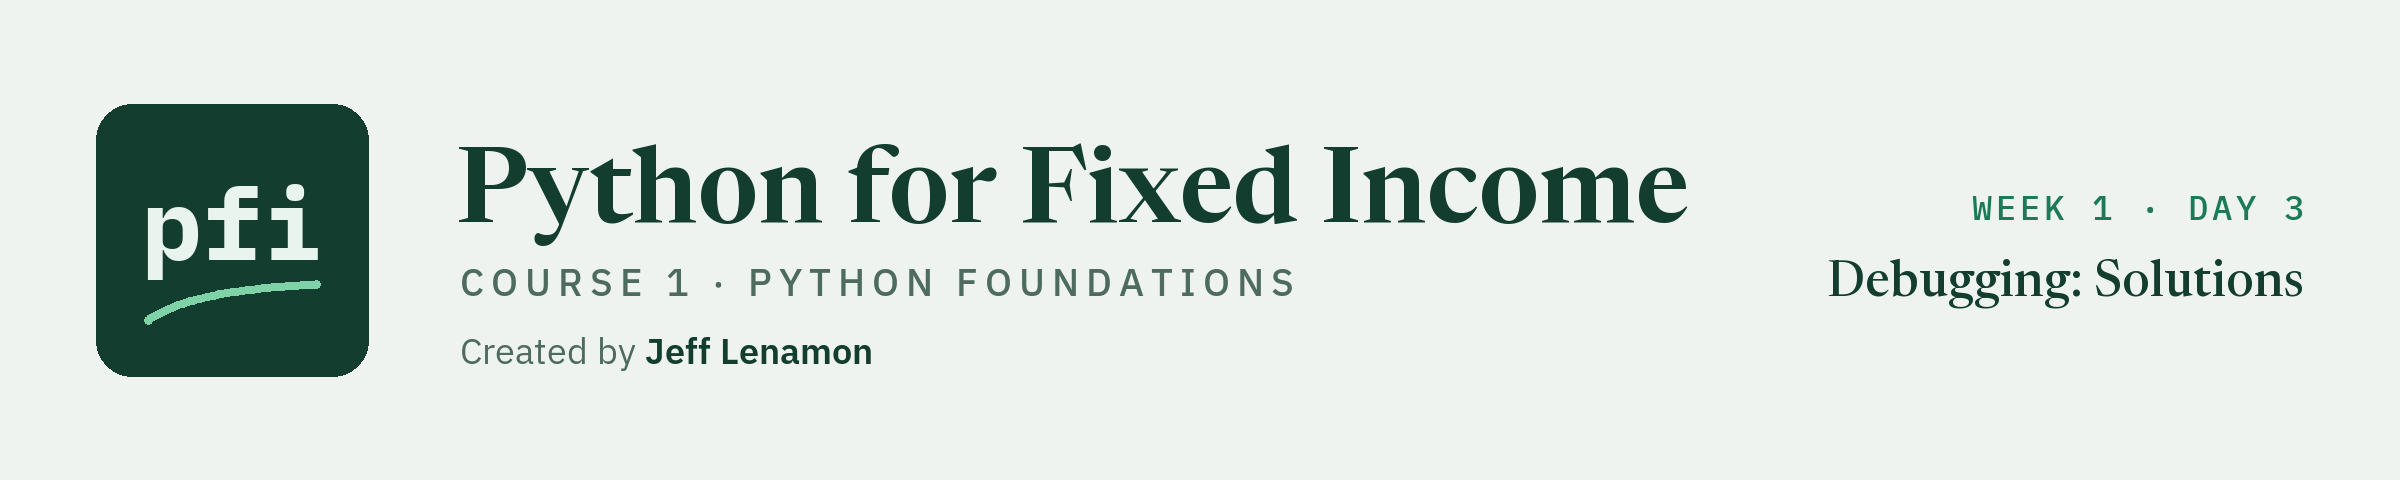

# Debugging - Solutions

Week 1. Worked answers to the exercises. Try each one yourself first.

> This course is educational content created in a personal capacity. Nothing here is investment advice or a recommendation to buy or sell any security. All portfolio data is synthetic.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/lenamonj/python-fixed-income/blob/main/course1_python_foundations/week1/day3/03_debugging_solutions.ipynb)

## Exercises

The analyst has also written code for a second desk, which holds three bonds. The issuers are invented.

| Ticker | Coupon (%) | Price | Rating | Score | Face held |
| --- | --- | --- | --- | --- | --- |
| TRNW | 4.375 | 96.25 | A | 6 | 2,000,000 |
| OSMC | 5.00 | 100.00 | BBB- | 10 | 1,250,000 |
| CLDB | 8.25 | 104.50 | B | 15 | 500,000 |

Exercises 1 to 5, 7, and 8 are each a piece of code with one bug. Run it, read what happens, fix the code **in the same cell**, and run it again. Exercise 6 asks you to write a function. Run the check cell under each one. Worked answers are in the solutions notebook in this folder.

Run the next cell first. It defines `check`, loads the desk's data, and sets each answer to the placeholder `...`.

In [1]:
def check(label, answer, expected):
    """Compare an exercise answer to the expected value and print the result."""
    if answer is ... or answer is None:
        print(label + ': not attempted yet')
    elif answer == expected:
        print(label + ': correct')
    else:
        print(label + ': not yet. You have', answer)


# the second desk's data
ticker_list = ['TRNW', 'OSMC', 'CLDB']
coupon_list = [4.375, 5.0, 8.25]
price_list = [96.25, 100.0, 104.5]
face_list = [2000000, 1250000, 500000]

# each answer starts as the placeholder ..., which check() reads as not attempted
ex1_total_face = ...
ex2_current_yield = ...
ex3_tickers = ...
ex4_average_price = ...
ex5_total_coupon = ...
ex5_bad_count = ...
ex6_average = ...
ex6_stops = ...
ex7_what_if = ...
ex8_ig_count = ...

### Exercise 1

Q. This code should total the face held. Fix it so that **ex1_total_face** holds the answer.

In [2]:
ex1_total_face = 0
# the colon at the end of the for line was missing
for face in face_list:
    ex1_total_face = ex1_total_face + face

print('The total face held is', ex1_total_face)

The total face held is 3750000


* It was a `SyntaxError`. The `for` line had no colon, so Python could not read the cell and none of it ran.

In [3]:
check('Exercise 1', ex1_total_face, 3750000)

Exercise 1: correct


### Exercise 2

Q. This code should compute the current yield of TRNW, rounded to 2 decimals. Fix it so that **ex2_current_yield** holds the answer.

In [4]:
bond = {'Ticker': 'TRNW', 'Coupon': 4.375, 'Price': 96.25}

# the keys are 'Coupon' and 'Price', with capital letters
ex2_current_yield = round(bond['Coupon'] / bond['Price'] * 100, 2)
print('The current yield of TRNW is', ex2_current_yield)

The current yield of TRNW is 4.55


* It was a `KeyError`. The code asked for 'coupon' and 'price', but the keys are stored as 'Coupon' and 'Price'. Fixing the first key reveals the second, so there were two places to change.

In [5]:
check('Exercise 2', ex2_current_yield, 4.55)

Exercise 2: correct


### Exercise 3

Q. This code should build a list of all three tickers by index. Fix it so that **ex3_tickers** holds the answer.

In [6]:
ex3_tickers = []
# three items sit at indexes 0, 1, and 2, so the range is range(3)
for i in range(3):
    ex3_tickers.append(ticker_list[i])

print(ex3_tickers)

['TRNW', 'OSMC', 'CLDB']


* It was an `IndexError`. `range(1, 4)` produced 1, 2, and 3, which skipped the first ticker and then asked for index 3, one past the end.

In [7]:
check('Exercise 3', ex3_tickers, ['TRNW', 'OSMC', 'CLDB'])

Exercise 3: correct


### Exercise 4

Q. The prices arrived from a file as text. This code should compute the simple average price. Fix it so that **ex4_average_price** holds the answer.

In [8]:
price_text_list = ['96.25', '100.0', '104.5']

total = 0
for text in price_text_list:
    # convert each price from text to a number before adding it
    total = total + float(text)

ex4_average_price = total / len(price_text_list)
print('The average price is', ex4_average_price)

The average price is 100.25


* It was a `TypeError`. The prices were strings, and Python cannot add a string to the number 0. `float()` converts each one first.

In [9]:
check('Exercise 4', ex4_average_price, 100.25)

Exercise 4: correct


### Exercise 5

Q. The coupons arrived as text, and one of them is 'TBD'. This code should add up the coupons that are numbers and count the ones that are not. Fix it with `try` and `except`, so that **ex5_total_coupon** and **ex5_bad_count** hold the answers.

In [10]:
coupon_text_list = ['4.375', 'TBD', '8.25']

ex5_total_coupon = 0
ex5_bad_count = 0
for text in coupon_text_list:
    try:
        # add the coupon if the text is a number
        ex5_total_coupon = ex5_total_coupon + float(text)
    except ValueError:
        # count the text that is not a number, and carry on
        ex5_bad_count = ex5_bad_count + 1

print(f'Total of the coupons that are numbers: {ex5_total_coupon}')
print(f'Values that are not numbers: {ex5_bad_count}')

Total of the coupons that are numbers: 12.625
Values that are not numbers: 1


In [11]:
check('Exercise 5 total', ex5_total_coupon, 12.625)
check('Exercise 5 bad values', ex5_bad_count, 1)

Exercise 5 total: correct
Exercise 5 bad values: correct


* `float('TBD')` raises a `ValueError`. Inside `try`, that sends Python to the `except` block, which counts the bad value, and the loop carries on.
* The error is named. A bare `except:` would also hide a misspelled name inside the loop.

### Exercise 6

Q. Write the function **average_price**. It takes a list of prices and returns their simple average. If the list is empty it must stop, with an `assert` and the message 'the price list is empty'.

In [12]:
def average_price(prices):
    """Return the simple average of a list of prices. Stop if the list is empty."""
    # an average of nothing has no meaning, so refuse it and say why
    assert len(prices) > 0, 'the price list is empty'
    return sum(prices) / len(prices)

In [13]:
ex6_average = average_price(price_list)

# does the function stop when it is handed an empty list?
if ex6_average is not None:
    try:
        average_price([])
        ex6_stops = False
    except AssertionError:
        ex6_stops = True

check('Exercise 6 average', ex6_average, 100.25)
check('Exercise 6 stops on an empty list', ex6_stops, True)

Exercise 6 average: correct
Exercise 6 stops on an empty list: correct


* The three prices average 100.25.
* Without the `assert`, an empty list would raise a `ZeroDivisionError`, which names the arithmetic. The message 'the price list is empty' names the cause.

### Exercise 7

Q. This code should leave the desk's `price_list` as it is, and build a second list, **ex7_what_if**, with CLDB marked at 99.5. It runs with no error. Fix it so that both checks pass.

In [14]:
price_list = [96.25, 100.0, 104.5]

# .copy() makes a separate list, so the desk's list is left alone
ex7_what_if = price_list.copy()
ex7_what_if[2] = 99.5

print(f'What-if prices: {ex7_what_if}')
print(f'Desk prices:    {price_list}')

What-if prices: [96.25, 100.0, 99.5]
Desk prices:    [96.25, 100.0, 104.5]


In [15]:
check('Exercise 7 what-if list', ex7_what_if, [96.25, 100.0, 99.5])
check('Exercise 7 desk list', price_list, [96.25, 100.0, 104.5])

Exercise 7 what-if list: correct
Exercise 7 desk list: correct


* `ex7_what_if = price_list` gave one list two names, so the new mark landed on the desk's list as well. `.copy()` makes a second list.
* The first check passes with or without the fix. The second check, on the list that was meant to stay the same, is the one that finds the bug.

### Exercise 8: AI check

You ask an AI assistant for code that counts how many of the three bonds are investment grade. A bond is investment grade when its rating score is 10 or lower. It gives you the code below. It was written for this course in the style of an AI answer, and it has one bug.

Q. Before you run it, count the investment grade bonds yourself from the table. Then run the code. Does it agree with you?

* From the table, TRNW (score 6) and OSMC (score 10) are investment grade, so the answer is 2. The original code printed 1, with no error.
* The bug was the comparison `score < 10`. That leaves out a score of exactly 10, which is BBB-, the lowest investment grade rating. The test has to be `score <= 10`.
* The mistake sits exactly on the boundary, which is where comparison bugs hide. Always test the value right at the line.

In [16]:
score_list = [6, 10, 15]

ex8_ig_count = 0
for score in score_list:
    # <= includes a score of exactly 10
    if score <= 10:
        ex8_ig_count = ex8_ig_count + 1

print('Investment grade bonds:', ex8_ig_count)

Investment grade bonds: 2


In [17]:
check('Exercise 8', ex8_ig_count, 2)

Exercise 8: correct
